# FER Emotion Recognition — Kaggle (Folder-Based)
### Model 1: Custom CNN (trained from scratch)
### Model 2: MobileNetV2 Transfer Learning (fully trainable + aggressive LR decay)

**Dataset:** `/kaggle/input/fer2013/train` & `/kaggle/input/fer2013/test`  
**Classes:** Angry, Happy, Sad, Surprise, Neutral (5 classes)  
**Input size:** 128×128 RGB

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout, Flatten
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

2026-03-09 16:55:46.648194: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773075346.826940      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773075346.883727      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773075347.294269      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773075347.294306      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773075347.294309      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Configuration

In [8]:
TRAIN_DIR  = '/kaggle/input/datasets/msambare/fer2013/train'
TEST_DIR   = '/kaggle/input/datasets/msambare/fer2013/test'

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
EPOCHS     = 40
NUM_CLASSES = 5

EMOTIONS = ['angry', 'happy', 'sad', 'surprise', 'neutral']

---
# Part 1 — Custom CNN Baseline
## 1.1 Data Generators for CNN

In [3]:
# CNN uses simple [0,1] normalisation
cnn_train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

cnn_train_data = cnn_train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    classes=EMOTIONS
)

cnn_val_data = cnn_train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    classes=EMOTIONS
)

cnn_test_gen = ImageDataGenerator(rescale=1./255)
cnn_test_data = cnn_test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    classes=EMOTIONS
)

Found 19341 images belonging to 5 classes.
Found 4835 images belonging to 5 classes.
Found 6043 images belonging to 5 classes.


## 1.2 Build CNN Model

In [4]:
def build_cnn(input_shape=(128, 128, 3), num_classes=5):
    l2 = regularizers.L2(1e-4)
    inp = Input(shape=input_shape)

    # Block 1
    x = Conv2D(32, (3,3), padding='same', activation='relu', kernel_regularizer=l2)(inp)
    x = BatchNormalization()(x)
    x = Conv2D(32, (3,3), padding='same', activation='relu', kernel_regularizer=l2)(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(2,2)(x)
    x = Dropout(0.25)(x)

    # Block 2
    x = Conv2D(64, (3,3), padding='same', activation='relu', kernel_regularizer=l2)(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3,3), padding='same', activation='relu', kernel_regularizer=l2)(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(2,2)(x)
    x = Dropout(0.25)(x)

    # Block 3
    x = Conv2D(128, (3,3), padding='same', activation='relu', kernel_regularizer=l2)(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3,3), padding='same', activation='relu', kernel_regularizer=l2)(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(2,2)(x)
    x = Dropout(0.25)(x)

    # Block 4
    x = Conv2D(256, (3,3), padding='same', activation='relu', kernel_regularizer=l2)(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, (3,3), padding='same', activation='relu', kernel_regularizer=l2)(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(2,2)(x)
    x = Dropout(0.25)(x)

    # Head
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2)(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2)(x)
    x = Dropout(0.4)(x)
    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out, name='cnn_baseline')
    return model

cnn_model = build_cnn()
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
cnn_model.summary()

I0000 00:00:1773066222.444480      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773066222.450558      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,275,429 (4.87 MB)

 Trainable params: 1,273,509 (4.86 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 1.3 Train CNN

In [5]:
cnn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_cnn.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

history_cnn = cnn_model.fit(
    cnn_train_data,
    epochs=EPOCHS,
    validation_data=cnn_val_data,
    callbacks=cnn_callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40


I0000 00:00:1773066231.274410     147 service.cc:152] XLA service 0x7a60900a6570 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773066231.274476     147 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773066231.274482     147 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773066232.532128     147 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-09 14:23:57.378537: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-09 14:23:57.532377: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-09 14:23:58.970617: E external/local_xl

  2/605 ━━━━━━━━━━━━━━━━━━━━ 49s 83ms/step - accuracy: 0.1797 - loss: 2.6059   

I0000 00:00:1773066248.726369     147 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


225/605 ━━━━━━━━━━━━━━━━━━━━ 2:02 321ms/step - accuracy: 0.2545 - loss: 1.8565

2026-03-09 14:25:24.349889: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-09 14:25:24.498354: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-09 14:25:25.295701: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-09 14:25:25.576351: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


605/605 ━━━━━━━━━━━━━━━━━━━━ 289s 439ms/step - accuracy: 0.2661 - loss: 1.7860 - val_accuracy: 0.3022 - val_loss: 1.7075 - learning_rate: 0.0010
Epoch 2/40
605/605 ━━━━━━━━━━━━━━━━━━━━ 135s 223ms/step - accuracy: 0.2931 - loss: 1.6755 - val_accuracy: 0.3160 - val_loss: 1.6330 - learning_rate: 0.0010
Epoch 3/40
605/605 ━━━━━━━━━━━━━━━━━━━━ 130s 215ms/step - accuracy: 0.3305 - loss: 1.6133 - val_accuracy: 0.2871 - val_loss: 1.6482 - learning_rate: 0.0010
Epoch 4/40
605/605 ━━━━━━━━━━━━━━━━━━━━ 131s 216ms/step - accuracy: 0.3768 - loss: 1.5296 - val_accuracy: 0.3766 - val_loss: 1.5451 - learning_rate: 0.0010
Epoch 5/40
605/605 ━━━━━━━━━━━━━━━━━━━━ 130s 215ms/step - accuracy: 0.4233 - loss: 1.4744 - val_accuracy: 0.3832 - val_loss: 1.5698 - learning_rate: 0.0010
Epoch 6/40
605/605 ━━━━━━━━━━━━━━━━━━━━ 136s 225ms/step - accuracy: 0.4992 - loss: 1.4053 - val_accuracy: 0.4732 - val_loss: 1.4353 - learning_rate: 0.0010
Epoch 7/40
605/605 ━━━━━━━━━━━━━━━━━━━━ 138s 229ms/step - accuracy: 0.5432 

## 1.4 Evaluate CNN

In [6]:
cnn_pred = cnn_model.predict(cnn_test_data)
cnn_acc  = accuracy_score(cnn_test_data.classes, np.argmax(cnn_pred, axis=1))
print(f'CNN Test Accuracy: {cnn_acc:.4f}')
print(classification_report(
    cnn_test_data.classes,
    np.argmax(cnn_pred, axis=1),
    target_names=EMOTIONS
))

189/189 ━━━━━━━━━━━━━━━━━━━━ 46s 241ms/step
CNN Test Accuracy: 0.7303
              precision    recall  f1-score   support

       angry       0.68      0.63      0.65       958
       happy       0.86      0.88      0.87      1774
         sad       0.68      0.51      0.59      1247
    surprise       0.82      0.85      0.83       831
     neutral       0.58      0.73      0.65      1233

    accuracy                           0.73      6043
   macro avg       0.73      0.72      0.72      6043
weighted avg       0.73      0.73      0.73      6043



## 1.5 Plot CNN History

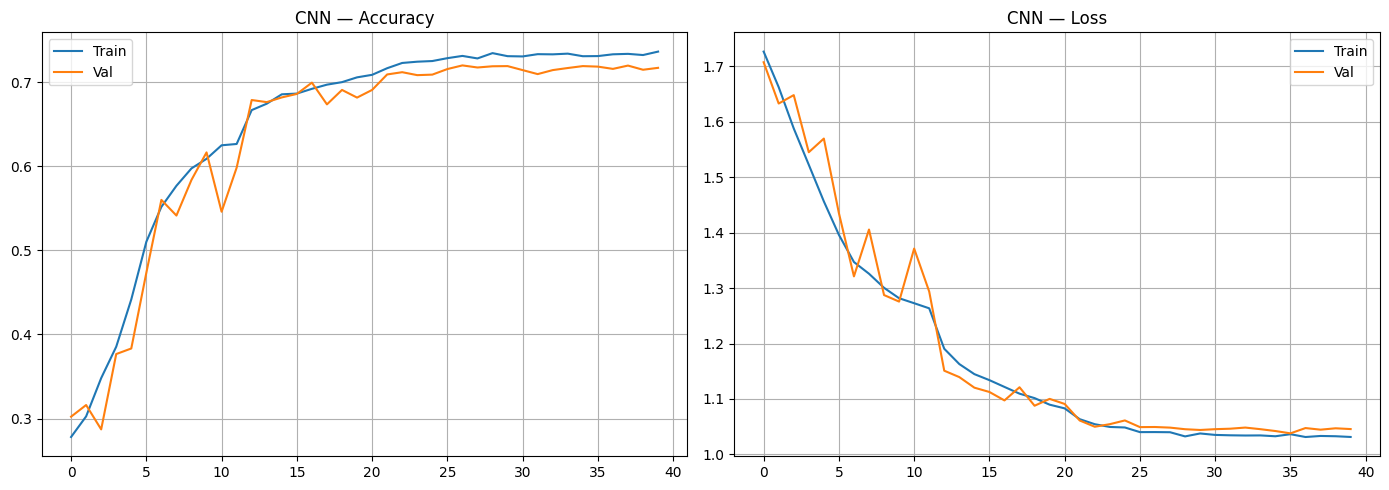

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_cnn.history['accuracy'],     label='Train')
ax1.plot(history_cnn.history['val_accuracy'], label='Val')
ax1.set_title('CNN — Accuracy'); ax1.legend(); ax1.grid(True)

ax2.plot(history_cnn.history['loss'],     label='Train')
ax2.plot(history_cnn.history['val_loss'], label='Val')
ax2.set_title('CNN — Loss'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig('cnn_history.png', dpi=150)
plt.show()

---
# Part 2 — MobileNetV2 Transfer Learning
Following the approach from the reference notebook:
- `preprocessing_function = mobilenet_v2.preprocess_input` (handles [-1,1] scaling correctly)
- **All layers trainable** from the start (no freeze/unfreeze stages)
- `ReduceLROnPlateau(factor=0.2, patience=2)` does automatic fine-tuning via LR drops
- `label_smoothing=0.1`

## 2.1 Data Generators for MobileNetV2

In [9]:
# MobileNetV2 requires its own preprocess_input (scales pixels to [-1, 1])
tl_train_gen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

tl_train_data = tl_train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    classes=EMOTIONS
)

tl_val_data = tl_train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    classes=EMOTIONS
)

tl_test_gen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)
tl_test_data = tl_test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    classes=EMOTIONS
)

Found 19341 images belonging to 5 classes.
Found 4835 images belonging to 5 classes.
Found 6043 images belonging to 5 classes.


## 2.2 Build MobileNetV2 Model

In [13]:
inputs    = Input(shape=(128, 128, 3))
base      = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs)

# All layers trainable from the start — LR schedule handles gradual fine-tuning
base.trainable = True

x = base.output

# Additional convolutional head on top of MobileNetV2 features
x = Conv2D(64,  (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2,2))(x)

x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model_tl = Model(inputs, outputs, name='mobilenetv2_fer')

model_tl.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model_tl.summary()

/tmp/ipykernel_55/3646066667.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base      = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs)
I0000 00:00:1773075715.077393      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_fer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 3,087,109 (11.78 MB)

 Trainable params: 3,052,613 (11.64 MB)

 Non-trainable params: 34,496 (134.75 KB)

## 2.3 Train MobileNetV2

In [14]:
tl_callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_mobilenet.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

history_tl = model_tl.fit(
    tl_train_data,
    epochs=EPOCHS,
    validation_data=tl_val_data,
      
    callbacks=tl_callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40


I0000 00:00:1773075751.231954     144 service.cc:152] XLA service 0x7ff0cc0160b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773075751.231991     144 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773075755.369194     144 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-09 17:02:44.149358: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-09 17:02:44.350882: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-09 17:02:44.548600: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

473/605 ━━━━━━━━━━━━━━━━━━━━ 35s 268ms/step - accuracy: 0.4144 - loss: 1.4742

2026-03-09 17:05:16.825190: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-09 17:05:17.026516: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-09 17:05:17.226472: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-09 17:05:17.422605: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


605/605 ━━━━━━━━━━━━━━━━━━━━ 294s 402ms/step - accuracy: 0.4356 - loss: 1.4364 - val_accuracy: 0.2676 - val_loss: 2.7606 - learning_rate: 0.0010
Epoch 2/40
605/605 ━━━━━━━━━━━━━━━━━━━━ 108s 178ms/step - accuracy: 0.6105 - loss: 1.1287 - val_accuracy: 0.4430 - val_loss: 1.6972 - learning_rate: 0.0010
Epoch 3/40
605/605 ━━━━━━━━━━━━━━━━━━━━ 109s 180ms/step - accuracy: 0.6414 - loss: 1.0795 - val_accuracy: 0.4949 - val_loss: 1.5645 - learning_rate: 0.0010
Epoch 4/40
605/605 ━━━━━━━━━━━━━━━━━━━━ 109s 180ms/step - accuracy: 0.6593 - loss: 1.0494 - val_accuracy: 0.5198 - val_loss: 1.4929 - learning_rate: 0.0010
Epoch 5/40
605/605 ━━━━━━━━━━━━━━━━━━━━ 108s 178ms/step - accuracy: 0.6693 - loss: 1.0300 - val_accuracy: 0.5268 - val_loss: 1.5066 - learning_rate: 0.0010
Epoch 6/40
605/605 ━━━━━━━━━━━━━━━━━━━━ 108s 179ms/step - accuracy: 0.6799 - loss: 1.0094 - val_accuracy: 0.6165 - val_loss: 1.1814 - learning_rate: 0.0010
Epoch 7/40
605/605 ━━━━━━━━━━━━━━━━━━━━ 108s 179ms/step - accuracy: 0.6890 

## 2.4 Evaluate MobileNetV2

In [16]:
tl_pred = model_tl.predict(tl_test_data)
tl_acc  = accuracy_score(tl_test_data.classes, np.argmax(tl_pred, axis=1))
print(f'MobileNetV2 Test Accuracy: {tl_acc:.4f}')
print(classification_report(
    tl_test_data.classes,
    np.argmax(tl_pred, axis=1),
    target_names=EMOTIONS
))

189/189 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step
MobileNetV2 Test Accuracy: 0.7562
              precision    recall  f1-score   support

       angry       0.74      0.62      0.67       958
       happy       0.88      0.90      0.89      1774
         sad       0.67      0.61      0.64      1247
    surprise       0.87      0.83      0.85       831
     neutral       0.62      0.76      0.68      1233

    accuracy                           0.76      6043
   macro avg       0.76      0.74      0.75      6043
weighted avg       0.76      0.76      0.76      6043



## 2.5 Plot MobileNetV2 History

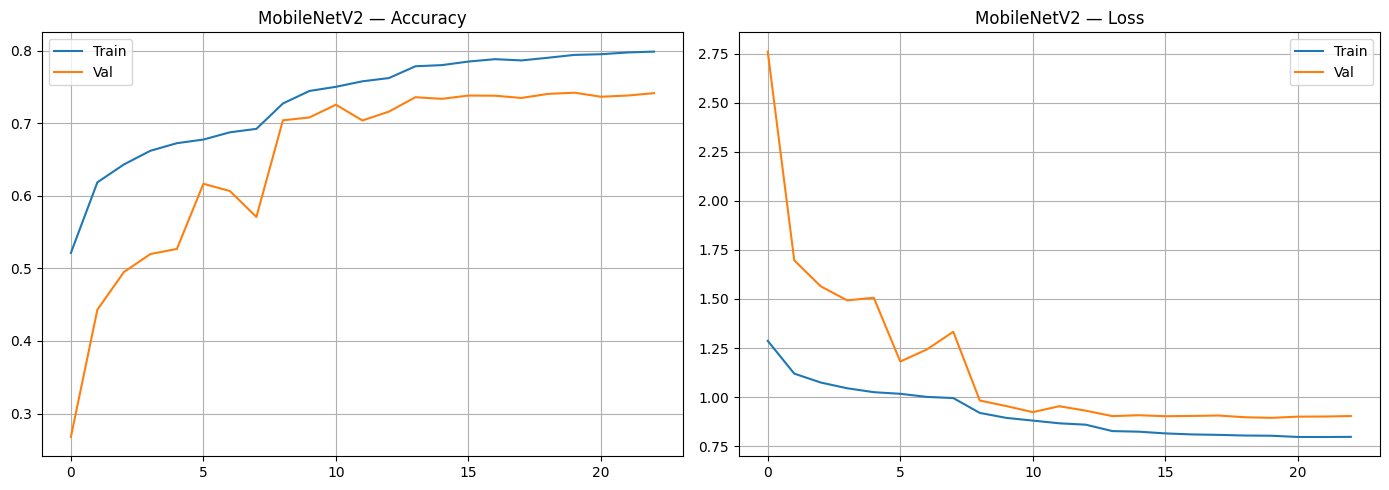

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_tl.history['accuracy'],     label='Train')
ax1.plot(history_tl.history['val_accuracy'], label='Val')
ax1.set_title('MobileNetV2 — Accuracy'); ax1.legend(); ax1.grid(True)

ax2.plot(history_tl.history['loss'],     label='Train')
ax2.plot(history_tl.history['val_loss'], label='Val')
ax2.set_title('MobileNetV2 — Loss'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig('tl_history.png', dpi=150)
plt.show()

---
# Final Comparison

In [20]:
print('=' * 40)
print(f'  CNN Baseline      : {cnn_acc*100:.2f}%')
print(f'  MobileNetV2 (TL)  : {tl_acc*100:.2f}%')
print(f'  Improvement       : {(tl_acc - cnn_acc)*100:+.2f}%')
print('=' * 40)

NameError: name 'cnn_acc' is not defined

## Save Models

In [19]:
cnn_model.save('fer_cnn_model.keras')
model_tl.save('fer_mobilenetv2_model.keras')
print('Both models saved.')

NameError: name 'cnn_model' is not defined